# Oil Pad detection — Mask R-CNN (Esri export, open-source stack)

Loads `Oil_PadSamplesOutput_batch16.emd` + `.pth` with **torchvision** only (no `arcpy`). Preprocesses multispectral tiles using statistics from the EMD JSON.

Place sample GeoTIFFs under `samples/` (3+ bands; bands `ExtractBands` from EMD are used). If none are found, the notebook runs on a **synthetic** chip in the training DN range for a smoke test.

**Environment (venv):** from the repo root: `python -m venv .venv`, activate (Windows: `.venv/Scripts/activate`, Unix: `source .venv/bin/activate`), then `pip install -r requirements.txt`. Optionally: `python -m ipykernel install --user --name esri-dlpk-notebook --display-name "ESRI DLPK notebook"`. Conda alternative: `environment.yml`.

In [33]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision.models.detection import maskrcnn_resnet50_fpn

try:
    import rasterio
except ImportError as e:
    raise ImportError("Install deps: pip install -r requirements.txt (or conda env from environment.yml)") from e

# Repo root = parent of notebooks/
REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

MODEL_DIR = REPO_ROOT / "Oil_PadSamplesOutput_batch16"
EMD_PATH = MODEL_DIR / "Oil_PadSamplesOutput_batch16.emd"
PTH_PATH = MODEL_DIR / "Oil_PadSamplesOutput_batch16.pth"
SAMPLES_DIR = REPO_ROOT / "samples"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
print("MODEL_DIR:", MODEL_DIR.resolve())

DEVICE: cpu
MODEL_DIR: D:\ESRI_dlpk\Oil_PadSamplesOutput_batch16


## 1. Load Esri Model Definition (JSON)

In [34]:
with open(EMD_PATH, encoding="utf-8") as f:
    emd = json.load(f)

classes = [c["Name"] for c in emd["Classes"]]
num_classes = 1 + len(emd["Classes"])  # background + objects
resize_to = int(emd.get("resize_to", emd["ImageHeight"]))
extract_bands = list(emd["ExtractBands"])

print("ModelName:", emd.get("ModelName"), "| backbone:", emd["ModelParameters"]["backbone"])
print("Classes:", classes, "-> num_classes (incl. bg):", num_classes)
print("resize_to:", resize_to, "| ExtractBands:", extract_bands)
print("ImageSpaceUsed:", emd.get("ImageSpaceUsed"), "| DoNormalize:", emd.get("DoNormalize"))
print("NormalizationStats keys:", list(emd["NormalizationStats"].keys()))

ModelName: MaskRCNN | backbone: resnet50
Classes: ['Oil Pad'] -> num_classes (incl. bg): 2
resize_to: 224 | ExtractBands: [0, 1, 2]
ImageSpaceUsed: MAP_SPACE | DoNormalize: False
NormalizationStats keys: ['band_min_values', 'band_max_values', 'band_mean_values', 'band_std_values', 'scaled_min_values', 'scaled_max_values', 'scaled_mean_values', 'scaled_std_values']


## 2. Build torchvision Mask R-CNN and load weights

The exported `.pth` is a flat `state_dict` compatible with `maskrcnn_resnet50_fpn(..., num_classes=2)` for one foreground class.

In [35]:
model = maskrcnn_resnet50_fpn(weights=None, weights_backbone=None, num_classes=num_classes)
try:
    state = torch.load(PTH_PATH, map_location=DEVICE, weights_only=True)
except TypeError:
    state = torch.load(PTH_PATH, map_location=DEVICE)
missing, unexpected = model.load_state_dict(state, strict=False)
assert not missing and not unexpected, (missing, unexpected)
model.to(DEVICE)
model.eval()
print("Checkpoint loaded; strict match OK.")

Checkpoint loaded; strict match OK.


## 3. Preprocessing (MAP_SPACE multispectral)

- Linear stretch each band to **[0, 1]** using `band_min_values` / `band_max_values` from the EMD.
- Then apply **scaled statistics**: `(x - scaled_mean_values) / scaled_std_values` per band (values are in the EMD). For this Oil Pad export, **skipping this step produced bogus detections**: boxes collapsed to the **right edge** (~1 pixel wide), so crops looked like colored vertical strips—not oil pads.
- The EMD field `DoNormalize` does **not** reliably mean “skip scaled stats”; treat **`APPLY_SCALED_NORM`** as the switch you tune. **Default below is `True`** for this model.

In [36]:
# Default True: matches Esri-style tensor stats for this export (see section 3 markdown).
APPLY_SCALED_NORM = True


def tensor_from_chw_float32(chw: np.ndarray) -> torch.Tensor:
    """chw: shape (3, H, W), float32"""
    return torch.from_numpy(np.ascontiguousarray(chw))


def preprocess_map_space(chw_dn: np.ndarray, stats: dict, apply_scaled_norm: bool) -> torch.Tensor:
    """
    chw_dn: float32 array (3, H, W) in raw / MAP_SPACE digital numbers.
    Returns float tensor (3, H, W) on CPU; move to DEVICE before inference.
    """
    mins = np.array(stats["band_min_values"], dtype=np.float32).reshape(3, 1, 1)
    maxs = np.array(stats["band_max_values"], dtype=np.float32).reshape(3, 1, 1)
    x = (chw_dn.astype(np.float32) - mins) / (maxs - mins + 1e-8)
    x = np.clip(x, 0.0, 1.0)
    if apply_scaled_norm:
        sm = np.array(stats["scaled_mean_values"], dtype=np.float32).reshape(3, 1, 1)
        ss = np.array(stats["scaled_std_values"], dtype=np.float32).reshape(3, 1, 1)
        x = (x - sm) / (ss + 1e-8)
    return tensor_from_chw_float32(x)


def read_chip_geotiff(path: Path, extract_bands: list[int], resize: int | None) -> np.ndarray:
    """Return float32 (3, H, W) from multiband raster."""
    with rasterio.open(path) as ds:
        if ds.count < max(b + 1 for b in extract_bands):
            raise ValueError(f"Need at least {max(b + 1 for b in extract_bands)} bands; got {ds.count}")
        arr = np.stack([ds.read(b + 1).astype(np.float32) for b in extract_bands], axis=0)
    if resize is not None and (arr.shape[1] != resize or arr.shape[2] != resize):
        # Simple box down/up-sample via two-step striding / repeat is poor; use torch interpolation
        t = torch.from_numpy(arr).unsqueeze(0)
        t = torch.nn.functional.interpolate(t, size=(resize, resize), mode="bilinear", align_corners=False)
        arr = t.squeeze(0).numpy()
    return arr


def rgb_preview(chw: np.ndarray, stats: dict) -> np.ndarray:
    """RGB uint8 using EMD global band min/max (same idea as training export)."""
    mins = np.array(stats["band_min_values"], dtype=np.float32).reshape(3, 1, 1)
    maxs = np.array(stats["band_max_values"], dtype=np.float32).reshape(3, 1, 1)
    x = (chw.astype(np.float32) - mins) / (maxs - mins + 1e-8)
    x = np.clip(x, 0, 1)
    return (np.transpose(x, (1, 2, 0)) * 255.0).astype(np.uint8)


def rgb_preview_percentile(chw: np.ndarray, lo: float = 2.0, hi: float = 98.0) -> np.ndarray:
    """Display-only RGB: per-band percentile stretch on this chip (easier to interpret than global EMD range)."""
    out = np.empty_like(chw, dtype=np.float32)
    for i in range(chw.shape[0]):
        plane = chw[i].astype(np.float32)
        a = float(np.percentile(plane, lo))
        b = float(np.percentile(plane, hi))
        b = max(b, a + 1e-6)
        out[i] = np.clip((plane - a) / (b - a), 0.0, 1.0)
    return (np.transpose(out, (1, 2, 0)) * 255.0).astype(np.uint8)


print("APPLY_SCALED_NORM:", APPLY_SCALED_NORM)

APPLY_SCALED_NORM: True


## 4. Load a sample chip (GeoTIFF or synthetic)

Using chip: d:\ESRI_dlpk\Oil_PadSamples_UAE\images\000000000000.tif


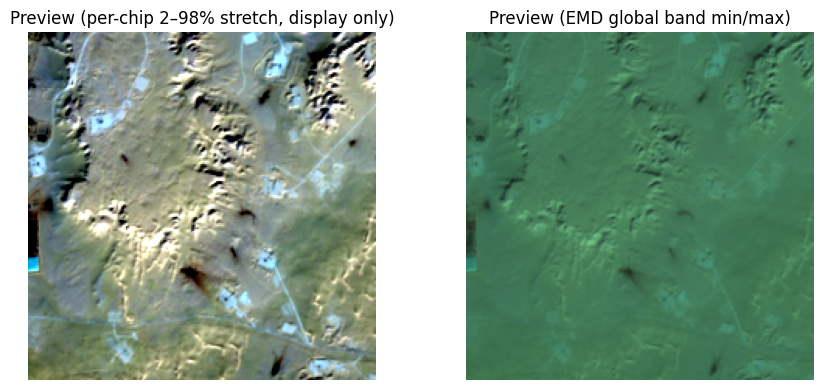

In [37]:
# Prefer UAE training chips (same domain as the model), then samples/, else synthetic random.
UAE_IMAGES = REPO_ROOT / "Oil_PadSamples_UAE" / "images"
DEFAULT_UAE_CHIP = UAE_IMAGES / "000000000000.tif"

paths_ordered = []
for p in (
    DEFAULT_UAE_CHIP,
    *sorted(UAE_IMAGES.glob("*.tif")),
    *sorted(UAE_IMAGES.glob("*.tiff")),
    *sorted(SAMPLES_DIR.glob("*.tif")),
    *sorted(SAMPLES_DIR.glob("*.tiff")),
):
    if p.is_file():
        rp = p.resolve()
        if rp not in {x.resolve() for x in paths_ordered}:
            paths_ordered.append(p)

if paths_ordered:
    chip_path = paths_ordered[0]
    print("Using chip:", chip_path)
    chip_dn = read_chip_geotiff(chip_path, extract_bands, resize_to)
else:
    print("No GeoTIFF found under Oil_PadSamples_UAE/images/ or samples/ — synthetic random chip (looks grainy)")
    rng = np.random.default_rng(0)
    stats_d = emd["NormalizationStats"]
    lo = np.array(stats_d["band_min_values"], dtype=np.float32)
    hi = np.array(stats_d["band_max_values"], dtype=np.float32)
    chip_dn = np.stack(
        [rng.uniform(lo[i], hi[i], size=(resize_to, resize_to)).astype(np.float32) for i in range(3)],
        axis=0,
    )

img_in = preprocess_map_space(chip_dn, emd["NormalizationStats"], APPLY_SCALED_NORM).to(DEVICE)
preview_pct = rgb_preview_percentile(chip_dn)
preview_emd = rgb_preview(chip_dn, emd["NormalizationStats"])

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(preview_pct)
axes[0].set_title("Preview (per-chip 2–98% stretch, display only)")
axes[0].axis("off")
axes[1].imshow(preview_emd)
axes[1].set_title("Preview (EMD global band min/max)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

# Background for detection overlay (next cell) — same as left panel
preview = preview_pct

## 5. Run inference and plot boxes / masks

Scores: [0.7792716  0.7441705  0.69918954 0.60376555 0.5448273  0.4825917
 0.3566248  0.34695083 0.324085   0.2959944  0.29523066 0.28401086
 0.27335975 0.26466465 0.26403046 0.25792956 0.22583532 0.16607481
 0.16305636 0.15918267 0.14511013 0.11734957 0.11712093 0.11338942
 0.09472972 0.09271473 0.09228875 0.09144159 0.0891961  0.08886704
 0.08081088 0.07481193 0.06738014 0.06271492 0.06195705 0.05975766
 0.05906761 0.05727268 0.05368824]
Labels: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1]
Boxes with score >= 0.2: 17 / 39


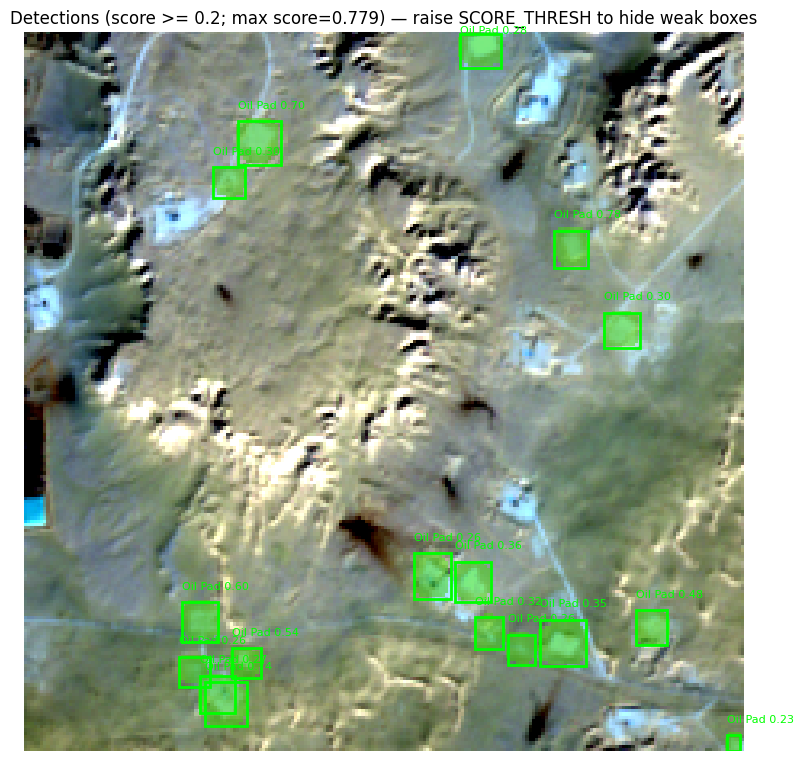

In [38]:
from matplotlib.patches import Rectangle
import torch.nn.functional as F

# Default 0.5 hides many valid Mask R-CNN hits (your max score was ~0.47).
SCORE_THRESH = 0.20

with torch.no_grad():
    preds = model([img_in])

p = preds[0]
scores_np = p["scores"].cpu().numpy()
labels_np = p["labels"].cpu().numpy()
print("Scores:", scores_np)
print("Labels:", labels_np)
print(f"Boxes with score >= {SCORE_THRESH}: {(scores_np >= SCORE_THRESH).sum()} / {len(scores_np)}")

h_img, w_img = preview.shape[:2]
mask_overlay = np.zeros((h_img, w_img, 4), dtype=np.float32)

for i in range(len(scores_np)):
    if float(scores_np[i]) < SCORE_THRESH:
        continue
    if "masks" in p and p["masks"] is not None and i < p["masks"].shape[0]:
        m = p["masks"][i, 0].float()[None, None]
        if m.shape[-2:] != (h_img, w_img):
            m = F.interpolate(m, size=(h_img, w_img), mode="nearest")
        m = m[0, 0].cpu().numpy() > 0.5
        mask_overlay[..., 0] = np.maximum(mask_overlay[..., 0], m.astype(np.float32) * 0.25)
        mask_overlay[..., 1] = np.maximum(mask_overlay[..., 1], m.astype(np.float32) * 0.85)
        mask_overlay[..., 3] = np.maximum(mask_overlay[..., 3], m.astype(np.float32) * 0.5)

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(preview)
if mask_overlay[..., 3].max() > 0:
    ax.imshow(mask_overlay)

for i in range(len(scores_np)):
    if float(scores_np[i]) < SCORE_THRESH:
        continue
    box = p["boxes"][i].cpu().numpy()
    x0, y0, x1, y1 = box
    rect = Rectangle(
        (x0, y0),
        x1 - x0,
        y1 - y0,
        linewidth=2,
        edgecolor="lime",
        facecolor="none",
        zorder=10,
    )
    ax.add_patch(rect)
    lab = int(labels_np[i].item())
    name = classes[lab - 1] if 1 <= lab <= len(classes) else str(lab)
    ax.text(
        x0,
        max(y0 - 4, 0),
        f"{name} {float(scores_np[i]):.2f}",
        color="lime",
        fontsize=8,
        zorder=11,
    )

ax.set_title(
    f"Detections (score >= {SCORE_THRESH}; max score={scores_np.max():.3f}) — raise SCORE_THRESH to hide weak boxes"
)
ax.axis("off")
plt.tight_layout()
plt.show()

## 6. Cropped detection patches

Runs after section 5. Each subplot shows the region inside the predicted box (with padding). Coordinates are **columns x / rows y** on the same pixel grid as `preview`.

**If crops looked like 1-pixel-wide vertical bars:** the model had predicted boxes with almost zero width along the right edge (`x ≈ image width`). That came from **wrong preprocessing** (scaled stats turned off). Re-run sections 3–5 with `APPLY_SCALED_NORM = True` (now the default).

preview shape (H,W)=(224,224), SCORE_THRESH=0.2, crops=17


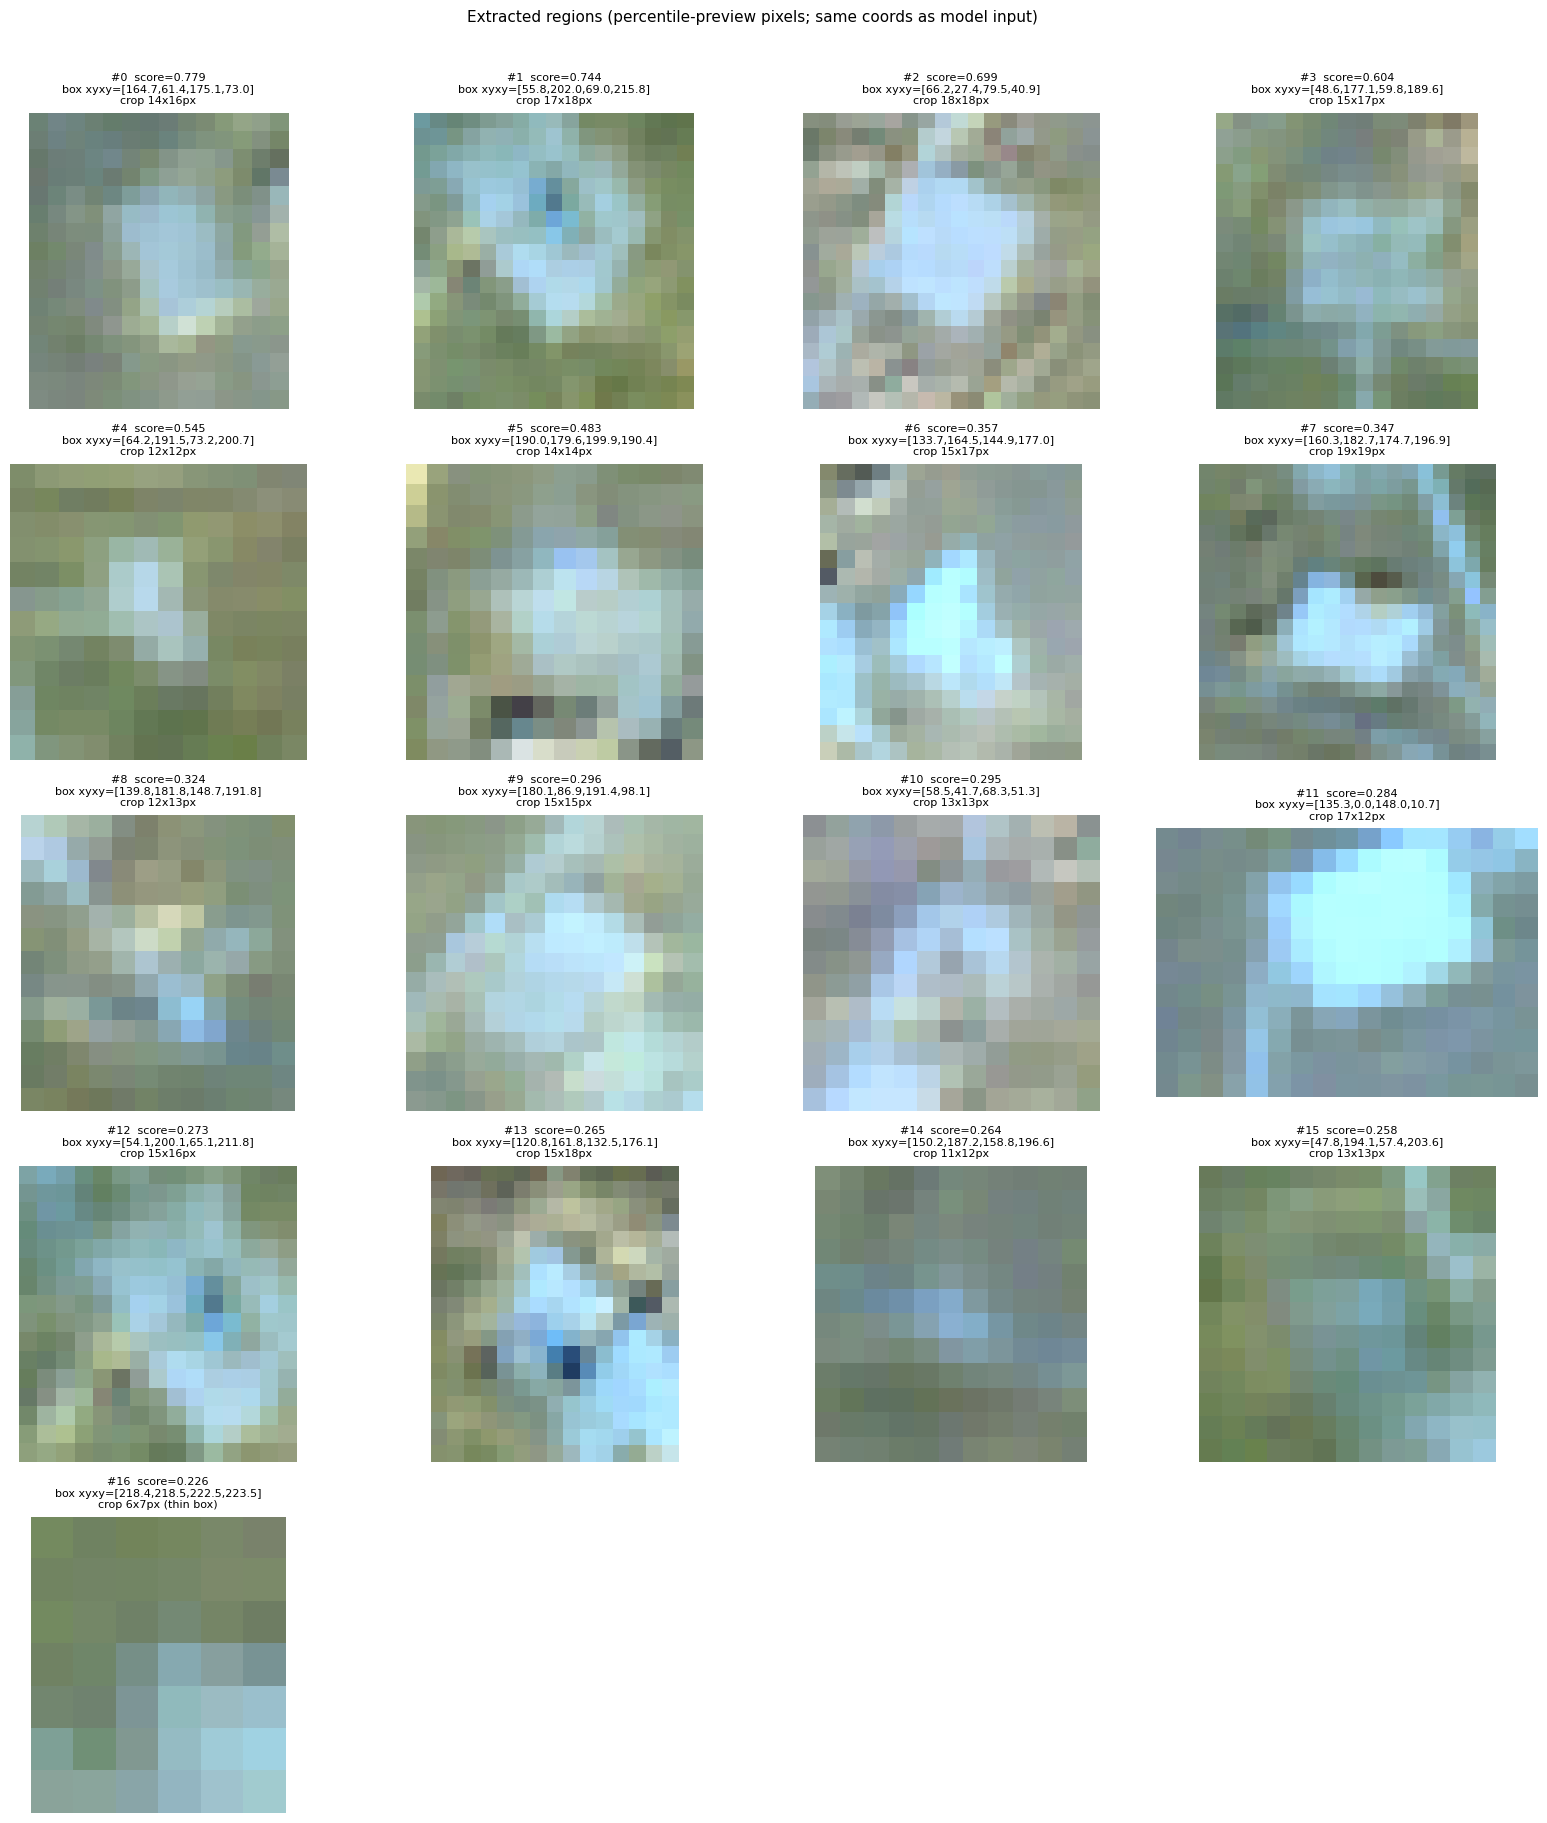

In [39]:
# Cropped patches for each detection (run section 5 first)
# Model boxes share the same pixel grid as `preview` (H x W). If xyxy shows x near W and tiny width,
# the network returned edge-collapsed boxes — crops will be thin strips (what you see is model output).

import numpy as np
import matplotlib.pyplot as plt

PAD_FRAC = 0.12  # expand box by this fraction of box width/height for context

h_img, w_img = preview.shape[:2]
mask_ok = scores_np >= SCORE_THRESH
order = np.argsort(-scores_np)

idxs = [i for i in order if mask_ok[i]]
print(f"preview shape (H,W)=({h_img},{w_img}), SCORE_THRESH={SCORE_THRESH}, crops={len(idxs)}")
if len(idxs) == 0:
    raise RuntimeError("No detections above threshold — lower SCORE_THRESH in the previous cell.")

cols = min(4, len(idxs))
rows = int(np.ceil(len(idxs) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.6 * rows))
axes = np.atleast_1d(axes).ravel()

for ax_idx, i in enumerate(idxs):
    ax = axes[ax_idx]
    box = p["boxes"][i].detach().cpu().numpy()
    x0, y0, x1, y1 = box.astype(np.float64)
    bw, bh = max(x1 - x0, 1e-6), max(y1 - y0, 1e-6)
    cx0 = int(np.floor(max(0, x0 - PAD_FRAC * bw)))
    cy0 = int(np.floor(max(0, y0 - PAD_FRAC * bh)))
    cx1 = int(np.ceil(min(w_img, x1 + PAD_FRAC * bw)))
    cy1 = int(np.ceil(min(h_img, y1 + PAD_FRAC * bh)))

    if cx1 <= cx0 or cy1 <= cy0:
        crop = np.zeros((32, 32, 3), dtype=np.uint8)
    else:
        crop = preview[cy0:cy1, cx0:cx1, :].copy()

    ax.imshow(crop)
    thin = (cx1 - cx0) < 8 or (cy1 - cy0) < 8
    ax.set_title(
        f"#{i}  score={scores_np[i]:.3f}\nbox xyxy=[{x0:.1f},{y0:.1f},{x1:.1f},{y1:.1f}]\ncrop {cx1-cx0}x{cy1-cy0}px{' (thin box)' if thin else ''}",
        fontsize=8,
    )
    ax.axis("off")

for j in range(len(idxs), len(axes)):
    axes[j].axis("off")

plt.suptitle(
    "Extracted regions (percentile-preview pixels; same coords as model input)",
    y=1.01,
    fontsize=11,
)
plt.tight_layout()
plt.show()


In [1]:
# Prefer UAE training chips (same domain as the model), then samples/, else synthetic random.
UAE_IMAGES = REPO_ROOT / "predictions"
DEFAULT_UAE_CHIP = UAE_IMAGES / "000000000001_pred.tif"

paths_ordered = []
for p in (
    DEFAULT_UAE_CHIP,
    *sorted(UAE_IMAGES.glob("*.tif")),
    *sorted(UAE_IMAGES.glob("*.tiff")),
    *sorted(SAMPLES_DIR.glob("*.tif")),
    *sorted(SAMPLES_DIR.glob("*.tiff")),
):
    if p.is_file():
        rp = p.resolve()
        if rp not in {x.resolve() for x in paths_ordered}:
            paths_ordered.append(p)

if paths_ordered:
    chip_path = paths_ordered[0]
    print("Using chip:", chip_path)
    chip_dn = read_chip_geotiff(chip_path, extract_bands, resize_to)
else:
    print("No GeoTIFF found under Oil_PadSamples_UAE/images/ or samples/ — synthetic random chip (looks grainy)")
    rng = np.random.default_rng(0)
    stats_d = emd["NormalizationStats"]
    lo = np.array(stats_d["band_min_values"], dtype=np.float32)
    hi = np.array(stats_d["band_max_values"], dtype=np.float32)
    chip_dn = np.stack(
        [rng.uniform(lo[i], hi[i], size=(resize_to, resize_to)).astype(np.float32) for i in range(3)],
        axis=0,
    )

img_in = preprocess_map_space(chip_dn, emd["NormalizationStats"], APPLY_SCALED_NORM).to(DEVICE)
preview_pct = rgb_preview_percentile(chip_dn)
preview_emd = rgb_preview(chip_dn, emd["NormalizationStats"])

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(preview_pct)
axes[0].set_title("Preview (per-chip 2–98% stretch, display only)")
axes[0].axis("off")
axes[1].imshow(preview_emd)
axes[1].set_title("Preview (EMD global band min/max)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

# Background for detection overlay (next cell) — same as left panel
preview = preview_pct

NameError: name 'REPO_ROOT' is not defined